<a href="https://colab.research.google.com/github/oda-so/Neuron_Models/blob/main/RUN003_MC_PosSweep_0226.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Changes made 18.02.26.
- Add HP filter
- Change sampling frequency to 1/30 kHz
- Change random position sweep
- Update synaptic weight
- Change windowing around peak_idx: from soma_max (global) to minimum lfp at channel with maximum negative deflection, per position

COMPARE CLOSELY TO Copy of Sim6_MC_Position_Sweep Notebook for reference!
This is a copy of the HAY position sweep!


# INSTALL AND IMPORT

In [ ]:
! pip install LFPy

In [ ]:
!pip install elephant

In [ ]:
import numpy as np
import sys
from urllib.request import urlopen
import ssl
from warnings import warn
import zipfile
import os
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import LFPy
import neuron
import pandas as pd
import json
import scipy.signal as ss
import elephant


# FETCH MC MODEL FILES

## Option A) Clone GitHub Repository Folder

In [ ]:
# STEP 1. Clone the repo (ROOT)
!git clone https://github.com/oda-so/Neuron_Models.git

Cloning into 'Neuron_Models'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 64 (delta 17), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 322.20 KiB | 4.96 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [ ]:
# Compile + load mechanisms (once per runtime)
%cd /content/Neuron_Models/L5_MC_bAC217_1
!cd mechanisms && nrnivmodl
neuron.load_mechanisms('mechanisms')
print('mechanisms loaded')


/content/Neuron_Models/L5_MC_bAC217_1
/content/Neuron_Models/L5_MC_bAC217_1/mechanisms
cfiles =
Mod files: "CaDynamics_E2.mod" "Ca_LVAst.mod" "Ca.mod" "Ih.mod" "Im.mod" "K_Pst.mod" "K_Tst.mod" "Nap_Et2.mod" "NaTa_t.mod" "NaTs2_t.mod" "ProbAMPANMDA_EMS.mod" "ProbGABAAB_EMS.mod" "SK_E2.mod" "SKv3_1.mod"

Creating 'x86_64' directory for .o files.

MODOBJS= ./CaDynamics_E2.o ./Ca_LVAst.o ./Ca.o ./Ih.o ./Im.o ./K_Pst.o ./K_Tst.o ./Nap_Et2.o ./NaTa_t.o ./NaTs2_t.o ./ProbAMPANMDA_EMS.o ./ProbGABAAB_EMS.o ./SK_E2.o ./SKv3_1.o
 -> Compiling mod_func.cpp
 -> NMODL ../CaDynamics_E2.mod
 -> NMODL ../Ca_LVAst.mod
 -> NMODL ../Ca.mod
Translating CaDynamics_E2.mod into /content/Neuron_Models/L5_MC_bAC217_1/mechanisms/x86_64/CaDynamics_E2.cpp
Translating Ca.mod into /content/Neuron_Models/L5_MC_bAC217_1/mechanisms/x86_64/Ca.cpp
Thread Safe
Thread Safe
Translating Ca_LVAst.mod into /content/Neuron_Models/L5_MC_bAC217_1/mechanisms/x86_64/Ca_LVAst.cpp
Thread Safe
 -> NMODL ../Ih.mod
 -> NMODL ../Im.mod
 

## Get template name

In [ ]:
# INSERT THIS INTO 'TEMPLATE' IN CELL PARAMETERS: bAC217_L5_MC_cc2a170ef6
!grep -n "begintemplate" template.hoc

35:begintemplate bAC217_L5_MC_cc2a170ef6


# HELPER FUNCTIONS

## TO_NATIVE()

In [ ]:
def _to_native(obj):
  if isinstance(obj, (np.integer,)):
    return int(obj)
  if isinstance(obj, (np.floating,)):
    return float(obj)
  if isinstance(obj, (np.ndarray,)):
    return obj.tolist()
  if isinstance(obj, (bytes, bytearray)):
    return obj.decode()
  return obj

## LATIN_HYPERCUBE()

In [ ]:
def latin_hypercube(rng, n, d):
  """
  Simple latin hypercube in [0,1]^d.
  Produces n points, d dimensions, space-filling (no clumps)
  """
  # Cut [0,1] into n strata, sample one point per statum per dimension
  cut = np.linspace(0, 1, n+1)
  u = rng.uniform(size=(n,d))
  a = cut[:n]
  b = cut[1:n+1]
  pts = a[:, None] + (b-a)[:, None]*u # shape (n,d) but same strata ordering per dim

  # Permute strata independently per dimension
  for j in range(d):
    rng.shuffle(pts[:,j])
  return pts

## SAMPLE_POSITIONS_LHS_WITH_MINMAX_DIST()

In [ ]:
def sample_positions_lhs_with_minmax_dist(rng, N, bounds, contacts_xyz, d_min=5.0, d_max = 70.0, max_tries=5000):
    (x_min, x_max), (y_min, y_max), (z_min, z_max) = bounds
    C = contacts_xyz  # shape (n_contacts, 3)

    accepted = []
    tries = 0

    # batch sampling helps performance
    batch = max(1000, N)

    while len(accepted) < N and tries < max_tries:
        tries += 1

        U = latin_hypercube(rng, batch, 3)
        xs = x_min + (x_max - x_min) * U[:, 0]
        ys = y_min + (y_max - y_min) * U[:, 1]
        zs = z_min + (z_max - z_min) * U[:, 2]

        P = np.column_stack([xs, ys, zs])  # (batch, 3)

        # compute min distance to any contact for each candidate
        # (batch, n_contacts) distances; use squared distances to be faster
        diff = P[:, None, :] - C[None, :, :]
        d2 = np.sum(diff**2, axis=-1)
        min_d = np.sqrt(d2.min(axis=1))

        ok = (min_d >= d_min)&(min_d <= d_max)
        for p in P[ok]:
            accepted.append(tuple(map(float, p)))
            if len(accepted) == N:
                break

    if len(accepted) < N:
        raise RuntimeError(f"Could only accept {len(accepted)}/{N} positions with d_min={d_min} µm. "
                           f"Relax d_min or expand bounds.")
    return accepted


## FIND_PEAK_INDICES()

In [ ]:
# PEAK FINDING AND 82-SAMPLE WINDOWING

def find_peak_indices(cell, electrode, mode='soma_max'):
  """
  mode:
  - 'soma_max': default, center on somatic V peak (AP maximum)
  - 'lfp_min': center on the most negative LFP sample across contacts
  - 'lfp_absmax': center on the largest |LFP| sample across contacts
  """
  if mode == 'soma_max':
    # index of maximum somatic voltage (AP peak)
    return int(np.argmax(cell.somav))

  elif mode == 'lfp_min':
    # global minimum across all contacts & time
    c, t = np.unravel_index(np.argmin(electrode.data), electrode.data.shape)
    return int(t)
  elif mode == 'lfp_absmax':
    c, t = np.unravel_index(np.argmax(np.abs(electrode.data)), electrode.data.shape)
    return int(t)

  else:
    raise ValueError("mode must be 'soma_max', 'lfp_min' or 'lfp_absmax'")



## EXTRACT_SNIPPET_AROUND()

In [ ]:

def extract_snippet_around(t_index, *arrays, n_total=82, tvec=None):
  """
  Take n_total consecutive samples centered on t_index (as much as possible),
  return slice_applied arrays and the slice used.

  Arguments:
  -----------
  t_index (int): central time index (e.g. from find_peak_indices)
  *arrays (arrays with time on the last axis): Any number of arrays to be sliced consistently
          Examples:
          - cell.somav       -> shape (T,)
          - electrode.data   -> shape (n_contacts, T)
          - cell.imem        -> shape (n_segments, T)
          All arrays must share the same length T on the last axis.

  n_total (int): number of samples in the window (default 82)
  tvec (1D array or None): if provided, used to
                      (a) deterimne total length and
                      (b) return a time vector shifted so the snippet starts at 0


  Returns:
  ---------
  If tvec is provided:
      (t_snip, arr1_snip, arr2_snip, ...), sl
  Else:
      (arr1_snip, arr2_snip, ...), sl
  Where sl is the Python slice used (slice(start,stop))
  """

  half = n_total // 2
  # Center like: [t_index - half : t_index + (n_total - half)]
  start = t_index - half
  stop = start + n_total

  # Determine total length T from tvec if available, else from first array
  T = len(tvec) if tvec is not None else arrays[0].shape[-1]

  # Clamp window so it stays within [0,T]
  if start < 0:
    start, stop = 0, n_total
  if stop > T:
    stop, start = T, T-n_total

  sl = slice(start, stop)

  # Slice all input arrays along the last axis
  out = []

  for arr in arrays:
    if arr.ndim == 1:
      out.append(arr[sl])
    else:
      out.append(arr[...,sl])

  # Also return time shifted so snippet start at 0
  if tvec is not None:
    t_snip = tvec[sl] - tvec[sl][0]
    return (t_snip, *out), sl

  else:
    return out, sl

## PLOTSTUFF()

In [ ]:
def plotstuff(cell, electrode, peak_mode = 'soma_max', n_total=82, debug=False):
    """
    Create a 3-panel figure:
    A: morphology + MEA colored by LFP amplitude, with star an max-deflection site
    B: somatic potential (82-sample window around chosen peak)
    C: extracellular potential at the max-deflection site (same window)

    peak_mode: 'soma_max', 'lfp_min' or 'lfp_absmax' (passed to find_peak_indices)
    n_total: number of time samples in the snippet (default 82)
    """

    # ==== 1. Windowing around the chosen peak ====
    peak_idx = find_peak_indices(cell, electrode, mode=peak_mode)
    (t_snip, somav_snip, lfp_snip), sl = extract_snippet_around(peak_idx, cell.somav, electrode.data, n_total = n_total, tvec=cell.tvec)

    if debug:
        print(f"T full = {cell.tvec.size}, snippet slice = {sl}, len_snip = {len(t_snip)}")
        print(f"somav full max = {cell.somav.max():.3f} mV at t = {cell.tvec[np.argmax(cell.somav)]:.3f} ms")
        print(f"somav_snip max = {somav_snip.max():.3f} mV at t = {t_snip[np.argmax(somav_snip)]:.3f} ms")


    # Sanity check: we really got n_total samples
    assert len(t_snip) == n_total, f"snippet length {len(t_snip)} != {n_total}"

    n_contacts, T_snip = lfp_snip.shape
    assert T_snip == n_total

    # ==== 2. Choose electrode with the largest deflection ====
    # Assuming negative-going deflection is of interest
    lfp_min_per_contact = lfp_snip.min(axis=1)   # (n_contacts,)
    star_idx = np.argmin(lfp_min_per_contact)    # index of most negative contact
    LFPtrace = lfp_snip[star_idx, :]             #

    # Compute amplitude measure for coloring:
    lfp_max_per_contact = lfp_snip.max(axis=1)
    amp = lfp_max_per_contact - lfp_min_per_contact     # ptp amplitude >= 0

    # ==== 3. Set up figure and Panel A (MEA + morphology) ====
    fig = plt.figure(dpi=160, figsize=(15,10))          # adjust figsize as desired

    ax1 = fig.add_axes([0.05, 0.1, 0.55, 0.9], frameon=False)
    cax = fig.add_axes([0.05, 0.115, 0.55, 0.015])

    # Plot MEA grid as light grey dots (background)
    ax1.plot(electrode.x, electrode.z, 'o', markersize=1, color='k', zorder=0)

    # Color-coded recording sites (log amplitude)
    amp_safe = np.maximum(amp, 1e-6)                    # avoid log10(0)
    scatter = ax1.scatter(
        electrode.x,
        electrode.z,
        c = np.log10(amp_safe),
        cmap = 'nipy_spectral',
        s=50,
        zorder=1,
        edgecolors='black',
        linewidths=0.5)

    # Colorbar
    axcb = fig.colorbar(scatter,cax=cax, orientation='horizontal')
    axcb.outline.set_visible(False)

    # Example tick based on min/max amplitude in linear scale
    a_min = amp_safe.min()
    a_max = amp_safe.max()
    if a_min <= 0:
        a_min = a_max /1000.0               # just in case

    # 4 tick points spaced log10 between min and max
    xticks_log = np.linspace(np.log10(a_min), np.log10(a_max), 4)
    axcb.set_ticks(xticks_log)
    axcb.set_ticklabels(np.round(10**xticks_log, decimals=3))
    axcb.set_label('LFP ptp amplitude (mV)', va='center')

    # Spatial scale bar (assuming units are µm)
    ax1.plot([60, 80], [100,100], color='k', lw=1)
    ax1.text(60, 102, '20 $\mu$m')

    ax1.set_xticks([])
    ax1.set_yticks([])

    axis_vals = ax1.axis(ax1.axis('equal'))
    ax1.set_xlim(axis_vals[0] * 1.02, axis_vals[1] *1.02)

    # Plot morphology
    zips = []
    for x, z in cell.get_pt3d_polygons():
        zips.append(list(zip(x,z)))
    from matplotlib.collections import PolyCollection
    polycol = PolyCollection(
        zips,
        edgecolors='none',
        facecolors='gray',
        zorder=-1,
        rasterized=False)
    ax1.add_collection(polycol)

    # Star on the max-deflection electrode
    ax1.plot(electrode.x[star_idx], electrode.z[star_idx], '*', markersize=8, markeredgecolor='none', markerfacecolor='k')

    ax1.text(-0.05, 0.95, 'a', horizontalalignment='center', verticalalignment='center', fontsize=16, fontweight='demibold', transform=ax1.transAxes)

    # ==== 4. Panel B: somatic potential ====
    ax2 = fig.add_axes([0.75, 0.6, 0.2, 0.35], frameon=True)

    # Use full snippet
    ax2.plot(t_snip, somav_snip, lw=1, color='k', clip_on=False)

    # Vertical markers
    t_ap = t_snip[np.argmax(somav_snip)]
    t_lfp_min = t_snip[np.argmin(LFPtrace)]
    t_lfp_max = t_snip[np.argmax(LFPtrace)]

    ax2.axvline(t_ap, ymin=0, ymax=1, linestyle='dashed', linewidth=0.5, color='k')
    ax2.axvline(t_lfp_min, ymin=0, ymax=1, linestyle='dashdot', linewidth=0.5, color='k')
    ax2.axvline(t_lfp_max, ymin=0, ymax=1, linestyle='dotted', linewidth=0.5, color='k')

    # Dynamic xticks
    t_max = t_snip[-1]
    n_xticks = 5
    xticks = np.linspace(0, t_max, n_xticks)
    ax2.set_xticks(xticks)
    ax2.set_xticklabels(np.round(xticks,1))

    ax2.set_ylabel(r'$V_\mathrm{soma}(t)$ (mV)')
    ax2.set_title('somatic potential', va='center')

    # Clean frame
    for loc, spine in ax2.spines.items():
        if loc in ['right', 'top']:
            spine.set_color('none')
    ax2.xaxis.set_ticks_position('bottom')
    ax2.yaxis.set_ticks_position('left')

    ax2.text(-0.3, 1.0, 'b',
             horizontalalignment='center',
             verticalalignment='center',
             fontsize=16, fontweight='demibold',
             transform=ax2.transAxes)

    # ==== 5. Panel C: extracellular spike at star_idx ====
    ax3 = fig.add_axes([0.75, 0.1, 0.2, 0.35], frameon=True)
    ax3.plot(t_snip, LFPtrace, lw=1, color='k', clip_on=False)

    # Optional: star at LFPminimum
    ax3.plot(t_lfp_min, LFPtrace.min(), '*',
             markersize=6, markeredgecolor='none', markerfacecolor='k')

    ax3.axvline(t_ap, ymin=0, ymax=1, linestyle='dashed', linewidth=0.5, color='k')
    ax3.axvline(t_lfp_min, ymin=0, ymax=1, linestyle='dashdot', linewidth=0.5, color='k')
    ax3.axvline(t_lfp_max, ymin=0, ymax=1, linestyle='dotted', linewidth=0.5, color='k')

    xticks= np.linspace(0, t_max, n_xticks)
    ax3.set_xticks(xticks)
    ax3.set_xticklabels(np.round(xticks,1))

    ax3.set_xlabel(r'$t$ (ms)', va='center')
    ax3.set_ylabel(r'$\Phi(\mathbf{r},t)$ (mV)')
    ax3.set_title('extracellular spike', va='center')

    for loc, spine in ax3.spines.items():
        if loc in ['right', 'top']:
            spine.set_color('none')
    ax3.xaxis.set_ticks_position('bottom')
    ax3.yaxis.set_ticks_position('left')

    ax3.text(-0.3, 1.0, 'c',
             horizontalalignment='center',
             verticalalignment='center',
             fontsize=16, fontweight='demibold',
             transform=ax3.transAxes)

    return fig

<>:77: SyntaxWarning: invalid escape sequence '\m'
<>:77: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-3213340188.py:77: SyntaxWarning: invalid escape sequence '\m'
  ax1.text(60, 102, '20 $\mu$m')


## PLOT_MORPHOLOGY_MEA()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.ticker import MultipleLocator


def plot_morphology_mea(cell,
                        electrode,
                        cell_position = (0.0, 0.0, 0.0),
                        cell_rotation = (0.0, 0.0, 0.0),
                        markersize=8):
  rx, ry, rz = cell_rotation
  cell.set_rotation(rx, ry, rz)

  dx, dy, dz = cell_position

  fig = plt.figure(dpi=160, figsize=(30,10))
  ax = fig.add_axes([0.10, 0.10, 0.85, 0.85], frameon=True)

  polys = []
  for x_arr, z_arr in cell.get_pt3d_polygons():
    x = np.asarray(x_arr, dtype=float) + dx
    z = np.asarray(z_arr, dtype=float) + dz
    polys.append(list(zip(x,z)))

  if polys:
    poly = PolyCollection(polys, facecolors='0.7', edgecolors='none', alpha=0.8, zorder=0)
    ax.add_collection(poly)

  ax.plot(electrode.x, electrode.z, 'o', ms=markersize, color='k', zorder=1)

  ax.set_aspect('equal', adjustable='box')
  ax.set_xlabel('x (um)')
  ax.set_ylabel('z (um)')
  #ax.xaxis.set_major_locator(MultipleLocator(5))
  #ax.yaxis.set_major_locator(MultipleLocator(5))
  ax.grid(False)

  ax.autoscale(enable=True, tight=True)
  ax.margins(0.05, 0.05)

  return fig



# GET MEA COORDINATES

In [ ]:
import numpy as np
xcoords = np.array([0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 0.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0], dtype=np.float64)
ycoords = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 18.0, 18.0, 18.0, 18.0, 18.0, 18.0, 18.0, 18.0, 24.0, 24.0, 24.0, 24.0, 24.0, 24.0, 24.0, 24.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 42.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 54.0, 54.0, 54.0, 54.0, 54.0, 54.0, 54.0, 54.0, 60.0, 60.0, 60.0, 60.0, 60.0, 60.0, 60.0, 60.0, 66.0, 66.0, 66.0, 66.0, 66.0, 66.0, 66.0, 66.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 72.0, 78.0, 78.0, 78.0, 78.0, 78.0, 78.0, 78.0, 78.0, 84.0, 84.0, 84.0, 84.0, 84.0, 84.0, 84.0, 84.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 96.0, 96.0, 96.0, 96.0, 96.0, 96.0, 96.0, 96.0, 102.0, 102.0, 102.0, 102.0, 102.0, 102.0, 102.0, 102.0, 108.0, 108.0, 108.0, 108.0, 108.0, 108.0, 108.0, 108.0, 114.0, 114.0, 114.0, 114.0, 114.0, 114.0, 114.0, 114.0, 120.0, 120.0, 120.0, 120.0, 120.0, 120.0, 120.0, 120.0, 126.0, 126.0, 126.0, 126.0, 126.0, 126.0, 126.0, 126.0, 132.0, 132.0, 132.0, 132.0, 132.0, 132.0, 132.0, 132.0, 138.0, 138.0, 138.0, 138.0, 138.0, 138.0, 138.0, 138.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 144.0, 150.0, 150.0, 150.0, 150.0, 150.0, 150.0, 150.0, 150.0, 156.0, 156.0, 156.0, 156.0, 156.0, 156.0, 156.0, 156.0, 162.0, 162.0, 162.0, 162.0, 162.0, 162.0, 162.0, 162.0, 168.0, 168.0, 168.0, 168.0, 168.0, 168.0, 168.0, 168.0, 174.0, 174.0, 174.0, 174.0, 174.0, 174.0, 174.0, 174.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 180.0, 186.0, 186.0, 186.0, 186.0, 186.0, 186.0, 186.0, 186.0, 192.0, 192.0, 192.0, 192.0, 192.0, 192.0, 192.0, 192.0, 198.0, 198.0, 198.0, 198.0, 198.0, 198.0, 198.0, 198.0, 204.0, 204.0, 204.0, 204.0, 204.0, 204.0, 204.0, 204.0, 210.0, 210.0, 210.0, 210.0, 210.0, 210.0, 210.0, 210.0, 216.0, 216.0, 216.0, 216.0, 216.0, 216.0, 216.0, 216.0, 222.0, 222.0, 222.0, 222.0, 222.0, 222.0, 222.0, 222.0, 228.0, 228.0, 228.0, 228.0, 228.0, 228.0, 228.0, 228.0, 234.0, 234.0, 234.0, 234.0, 234.0, 234.0, 234.0, 234.0, 240.0, 240.0, 240.0, 240.0, 240.0, 240.0, 240.0, 240.0, 246.0, 246.0, 246.0, 246.0, 246.0, 246.0, 246.0, 246.0, 252.0, 252.0, 252.0, 252.0, 252.0, 252.0, 252.0, 252.0, 258.0, 258.0, 258.0, 258.0, 258.0, 258.0, 258.0, 258.0, 264.0, 264.0, 264.0, 264.0, 264.0, 264.0, 264.0, 264.0, 270.0, 270.0, 270.0, 270.0, 270.0, 270.0, 270.0, 270.0, 276.0, 276.0, 276.0, 276.0, 276.0, 276.0, 276.0, 276.0, 282.0, 282.0, 282.0, 282.0, 282.0, 282.0, 282.0, 282.0], dtype=np.float64)

# SIMULATION PARAMETERS

In [ ]:
# Define paths
MODEL_ROOT = '/content/Neuron_Models/L5_MC_bAC217_1'
TEMPLATE = 'bAC217_L5_MC_cc2a170ef6'

In [ ]:
# Make the model folder CWD so that relative load_file("...") calls inside template.hoc will succeed.
%cd /content/Neuron_Models/L5_MC_bAC217_1

# ==== CELL MODEL PARAMETERS ====
cellParameters = {
    'morphology'    : f'{MODEL_ROOT}/morphology/C040601.asc',  # geometry, okay with relative path regardelss of CWD
    'templatefile'  : ['template.hoc'], # <-- RELATIVE path, only use template.hoc
    'templatename'  : 'bAC217_L5_MC_cc2a170ef6',  # hook NEURON's template
    'templateargs'  : 0,    # numeric: 0 = no synapses, 1 = with synapses
    'passive' : False,
    'nsegs_method' : None,
    'dt' :  1/30,   # should be power of 2. Time resolution for simulation, should match exp. data. AP spike band sampled at 30kHz.
    'tstart' : 0,
    'tstop' : 500,
    'v_init' : -60,
    'celsius': 34,
    'pt3d' : True,
}

# ==== ELECTRODE GEOMETRY ====

x_flat = np.asarray(xcoords).ravel().astype(float)
z_flat = np.asarray(ycoords).ravel().astype(float) # map exp 'y' -> plot 'z'
y_plane = np.zeros_like(x_flat)

n_contacts = x_flat.size

electrodeParameters = {
    'sigma' : 0.3,                      # extracellular conductivity
    'x' : x_flat,                       # x,y,z-coordinates of contacts
    'y' : y_plane,
    'z' : z_flat,
    'method' : 'pointsource',                       # 'pointsource' / 'linesource' /'root_as_point'  # sphere source soma segment
    # 'normal' : [0.0, 1.0, 0.0],                   # surface normals, intended shape is a single 3-vector broadcast to all versions. Not supported in this environment; 'normal' is not intercepted at the pad-averaging layer
    'N': np.tile([0.0, 1.0, 0.0], (n_contacts, 1)), # Consider removing, should work fine with defaults. Explicit per-contact normals, shape must match number of contacts. In this stack: N is consumed by the electrode wrapper to build averaging disks and is not forwarded to low-level calc_lfp_* functions.
    'contact_shape': 'square',
    'r' : 2.5,                          # contact site radius
    'n' : 40,                           # datapoints for averaging, spatial averaging over contact area
}

/content/Neuron_Models/L5_MC_bAC217_1


# SOMA SYNAPTIC INPUT STIMULUS

## Test Cell with Synaptic Input

In [ ]:
# ==== 1) Cell ====
# delete old instances
LFPy.cell.neuron.h("forall delete_section()")
# instantiate cell object
my_cell = LFPy.TemplateCell(**cellParameters)

# set orientation and position
my_cell.set_rotation(x=4.749, y=-3.166, z=3.0)
my_cell.set_pos(25.0, 0.0, 120.0)

# if instantiating again inside the same kernel, do not load the HOC again:
# cellParameters['templatefile'] = []   # avoid "template cannot be redefined"
# my_cell2 = LFPy.TemplateCell(**cellParameters)

# === 2) Synapse ====
# define synapse parameters
synapseParameters={
    'idx' : my_cell.somaidx[0],
    'syntype': 'Exp2Syn', # two-exponential synapse
    'e': 0.0, # reversal potential (mV), standard for excitatory synapse
    'tau1' : 0.5,
    'tau2' : 3.0,
    'weight': 0.005, # TBD
    'record_current': True,
}
# instantiate synapse
my_synapse = LFPy.Synapse(cell=my_cell, **synapseParameters)
input_spike_train = np.array([450.0])
my_synapse.set_spike_times(input_spike_train)

# ==== 3) Electrode ====
# instantiate electrode object for LFPs on grid
my_electrode = LFPy.RecExtElectrode(cell=my_cell, **electrodeParameters)

# ==== 4) Simulate ====
# Simulated results saved as attribute 'data' in the RecExtElectrode instance
my_cell.simulate(probes=[my_electrode], rec_imem=True, rec_vmem=True)


	1 
	1 
	1 


# HP FILTER (TB 30.01.26)

In [ ]:
### FILTER (FRA TB 30.01.26)
import scipy.signal as ss
import elephant

filt_dict_band_pass = {'highpass_frequency': 300,       # specified in literature
                        'lowpass_frequency': 10000,    # indicated in literature
                        'order': 1,
                        'filter_function': 'filtfilt',
                        'sampling_frequency': 1 / (my_cell.dt / 1000),
                        'axis': -1
                           }

# band-pass filter settings
Fs = 1000 / my_cell.dt    # Hz (dt in ms)
N = 1  # filter order
rp = 0.1  # ripple in passband (dB)
rs = 40.  # minimum attenuation required in the stop band (dB)
hp = 300.  # critical frequency (Hz)
lp = 10000. #

# filter coefficients on 'sos' format
sos_ellip = ss.ellip(N=N, rp=rp, rs=rs, Wn=[hp, lp],
                         btype='bp', fs=Fs, output='sos')
# HVIS LOW_PASS, ENDRE TIL btype fra HP til BP

#electrode = LFPy.RecExtElectrode(my_cell, **elec_params)
#imem_filt = elephant.signal_processing.butter(my_cell.imem,
                                                  #**filt_dict_band_pass)
imem_filt2 = ss.sosfiltfilt(sos_ellip, my_cell.imem)
#v_e_ufilt = electrode.get_transformation_matrix() @ my_cell.imem * 1e3

# Plotte cell.imem og imem_filt2 mot hverandre
#my_cell.imem = imem_filt2
# kan være litt annerledes, ingen voldsomme forskjeller (særlig i endene)

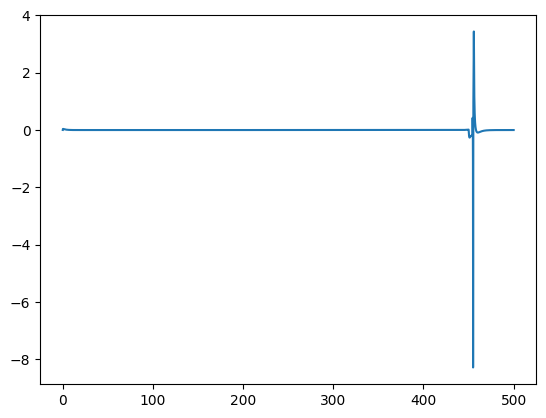

In [ ]:
# FILTERED
plt.plot(my_cell.tvec, imem_filt2[0])

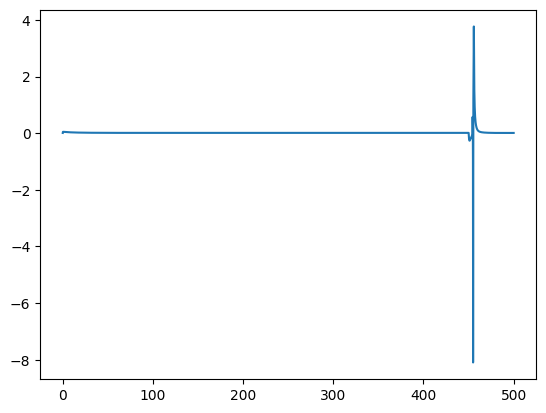

In [ ]:
# NON-FILTERED
plt.plot(my_cell.tvec, my_cell.imem[0])

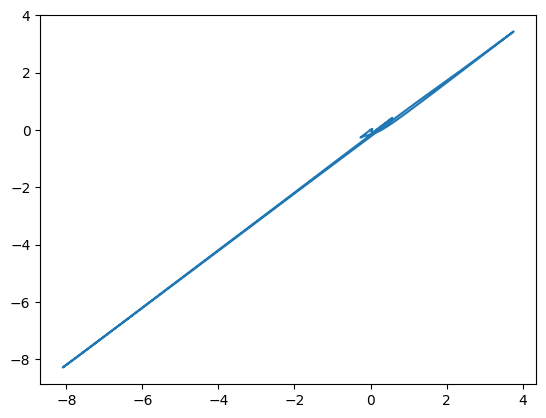

In [ ]:
# NON-FILTERED VS FILTERED
plt.plot(my_cell.imem[0], imem_filt2[0])

### Sanity check vector shapes

In [ ]:
# Sanity check
print("somav shape: ", my_cell.somav.shape)
print("tvec shape: ", my_cell.tvec.shape)
print("electrode.data shape: ", my_electrode.data.shape)
assert my_cell.somav.ndim == 1
n_contacts, T = my_electrode.data.shape
assert T == my_cell.tvec.size   # electrode.data and tvec must have same length

somav shape:  (15001,)
tvec shape:  (15001,)
electrode.data shape:  (384, 15001)


### Check peak_idx in mode 'lfp_min' vs. 'soma_max'

In [ ]:
# Sanity check
peak_idx = find_peak_indices(my_cell, my_electrode, mode='soma_max')
print("Peak index: ", peak_idx, "t_peak: ", my_cell.tvec[peak_idx])

(T_snip, mode) = (82, 'soma_max')
(t_snip, somav_snip, lfp_snip), sl = extract_snippet_around(peak_idx, my_cell.somav, my_electrode.data, n_total=T_snip, tvec=my_cell.tvec)

print("PEAK IDX FOUND IN MODE SOMA_MAX")
print("Slice: ", sl)
print("len(t_snip):" , len(t_snip))
print("somav_snip max at index: ", np.argmax(somav_snip), "t (ms): ", t_snip[np.argmax(somav_snip)])
print("somav max at index: ", np.argmax(my_cell.somav))
print(f"somav max = {my_cell.somav.max():.2f} mV")
print(f"somav_snip max: {somav_snip.max():.2f} mV")

print("lfp_snip shape: ", lfp_snip.shape)
print("t_snip shape: ", t_snip.shape)

c_min_snip, t_min_snip = np.unravel_index(np.argmin(lfp_snip), lfp_snip.shape)
print("lfp_snip global min at channel:", c_min_snip, "time index:", t_min_snip, "t (ms):", t_snip[t_min_snip])
print("lfp_snip min value:", lfp_snip[c_min_snip, t_min_snip])

c_min, t_min = np.unravel_index(np.argmin(my_electrode.data), my_electrode.data.shape)
print("lfp global min at channel:", c_min, "time index:", t_min, "t (ms):", my_cell.tvec[t_min])
print("lfp min value:", lfp_snip[c_min, t_min])


print("lfp_snip min at index: ", np.argmin(lfp_snip), "t (ms): ", t_snip[np.argmin(lfp_snip)])
print("full lfp min at index: ", np.argmin(my_electrode.data.min(axis=1)))
print(f"full lfp min = {my_electrode.data.min(axis=1):.2f} mV")
print(f"lfp snip min: {lfp_snip.min():.2f} mV")

Peak index:  13652 t_peak:  455.0666666668131
PEAK IDX FOUND IN MODE SOMA_MAX
Slice:  slice(13611, 13693, None)
len(t_snip): 82
somav_snip max at index:  41 t (ms):  1.3666666666677543
somav max at index:  13652
somav max = 22.62 mV
somav_snip max: 22.62 mV
lfp_snip shape:  (384, 82)
t_snip shape:  (82,)


IndexError: index 13487 is out of bounds for axis 0 with size 82

In [ ]:
# Compare to using peak_idx with lfp_min
peak_idx_lfp = find_peak_indices(my_cell, my_electrode, mode='lfp_min')
print("Peak index (lfp min): ", peak_idx_lfp, "t_peak: ", my_cell.tvec[peak_idx_lfp])

(T_snip, mode) = (82, 'lfp_min')
(t_snip, somav_snip, lfp_snip), sl = extract_snippet_around(peak_idx_lfp, my_cell.somav, my_electrode.data, n_total=T_snip, tvec=my_cell.tvec)

print("PEAK IDX FOUND IN MODE LFP_MIN")
print("Slice: ", sl)
print("len(t_snip):" , len(t_snip))
print("somav_snip max at index: ", np.argmax(somav_snip), "t (ms): ", t_snip[np.argmax(somav_snip)])
print("somav max at index: ", np.argmax(my_cell.somav))
print(f"somav max = {my_cell.somav.max():.2f} mV")
print(f"somav_snip max: {somav_snip.max():.2f} mV")

print("lfp_snip min at index: ", np.argmin(lfp_snip), "t (ms): ", t_snip[np.argmin(lfp_snip)])
print("full lfp min at index: ", np.argmin(my_electrode.data.min(axis=1)))
print(f"full lfp min = {my_electrode.data.min():.2f} mV")
print(f"lfp snip min: {lfp_snip.min():.2f} mV")

Peak index (lfp min):  13650 t_peak:  455.0000000001464
PEAK IDX FOUND IN MODE LFP_MIN
Slice:  slice(13609, 13691, None)
len(t_snip): 82
somav_snip max at index:  43 t (ms):  1.433333333334474
somav max at index:  13652
somav max = 22.62 mV
somav_snip max: 22.62 mV


IndexError: index 13489 is out of bounds for axis 0 with size 82

# PLOT CELL AND MEA

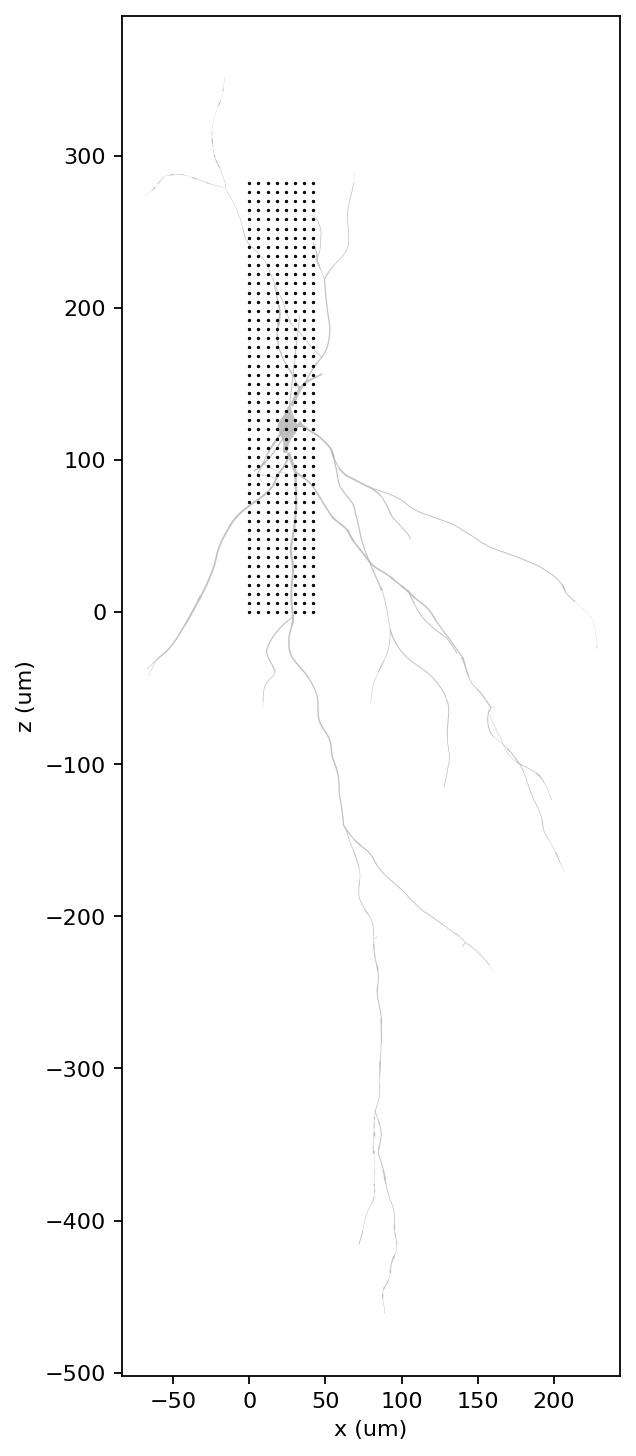

In [ ]:

figure= plot_morphology_mea(my_cell,
                        my_electrode,
                        cell_position = (0.0, 0.0, 0.0),    # relative to previously defined position, when set in plot_morphology_mea()
                        cell_rotation = (0.0, 0.0, 0.0),
                        markersize=0.5)

## PLOTSTUFF() FIGURE

T full = 15001, snippet slice = slice(13611, 13693, None), len_snip = 82
somav full max = 22.622 mV at t = 455.067 ms
somav_snip max = 22.622 mV at t = 1.367 ms


/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1987: PyparsingDeprecationWarning: 'setParseA

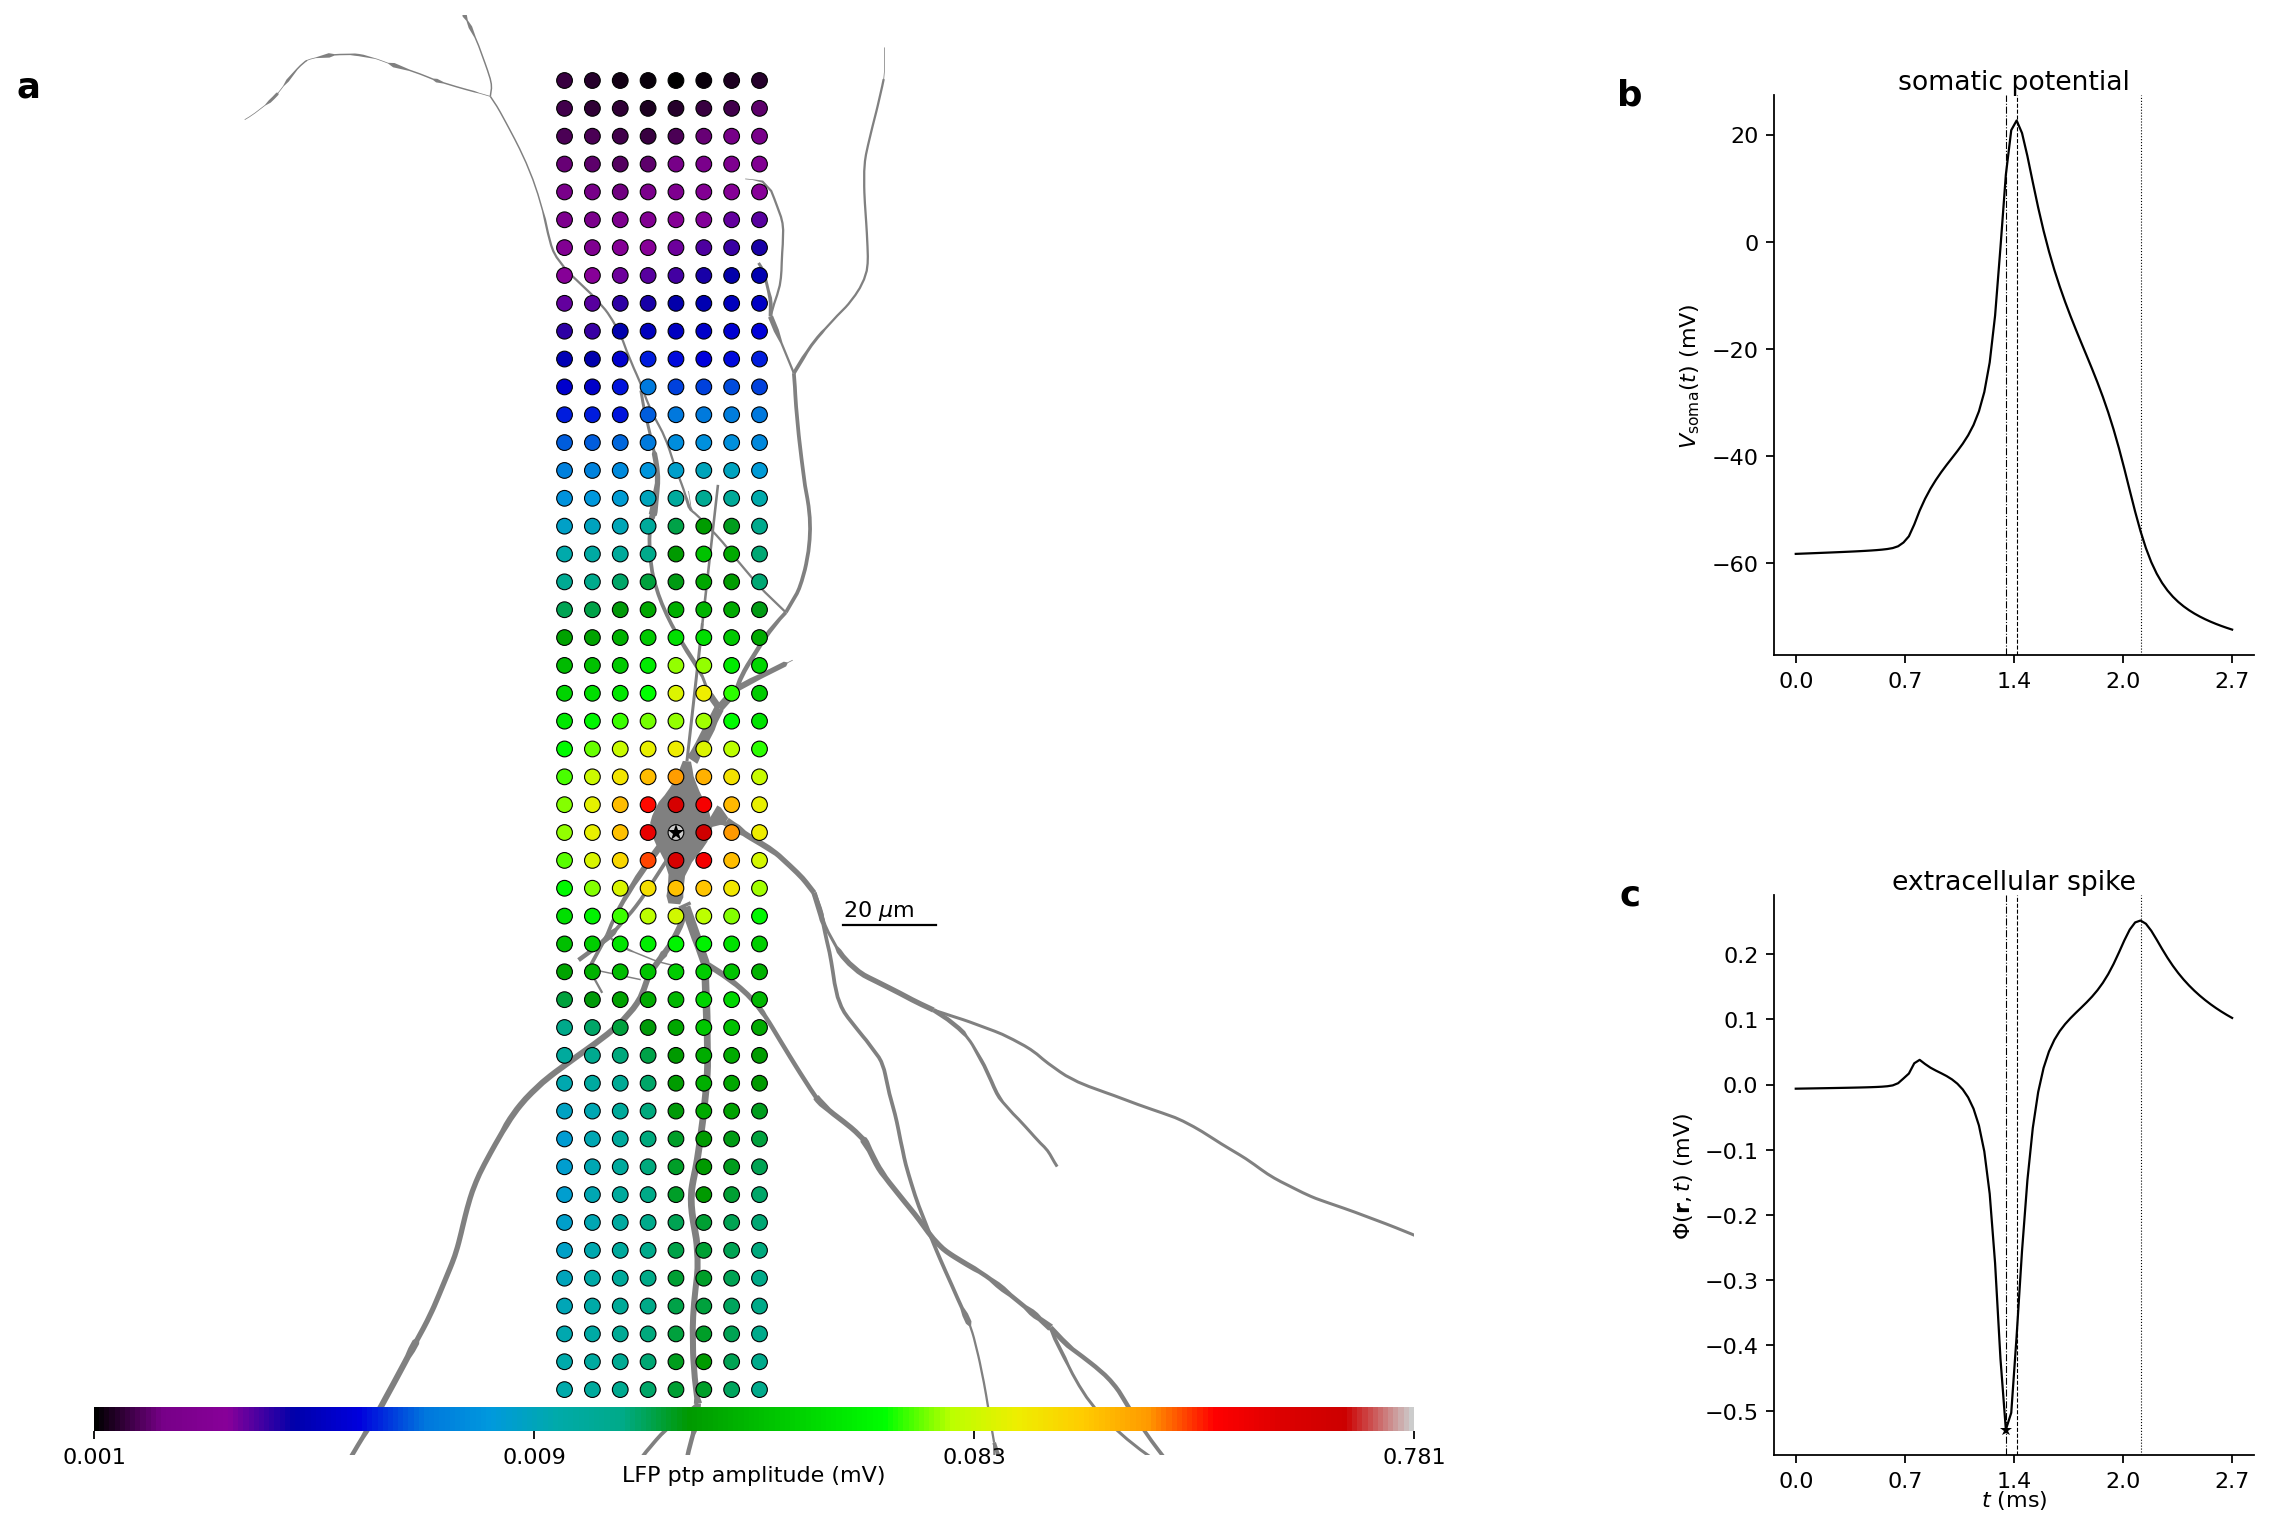

In [ ]:
fig = plotstuff(my_cell, my_electrode, peak_mode='soma_max', n_total=82, debug=True)
plt.show()

T full = 15001, snippet slice = slice(13611, 13693, None), len_snip = 82
somav full max = 22.622 mV at t = 455.067 ms
somav_snip max = 22.622 mV at t = 1.367 ms


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


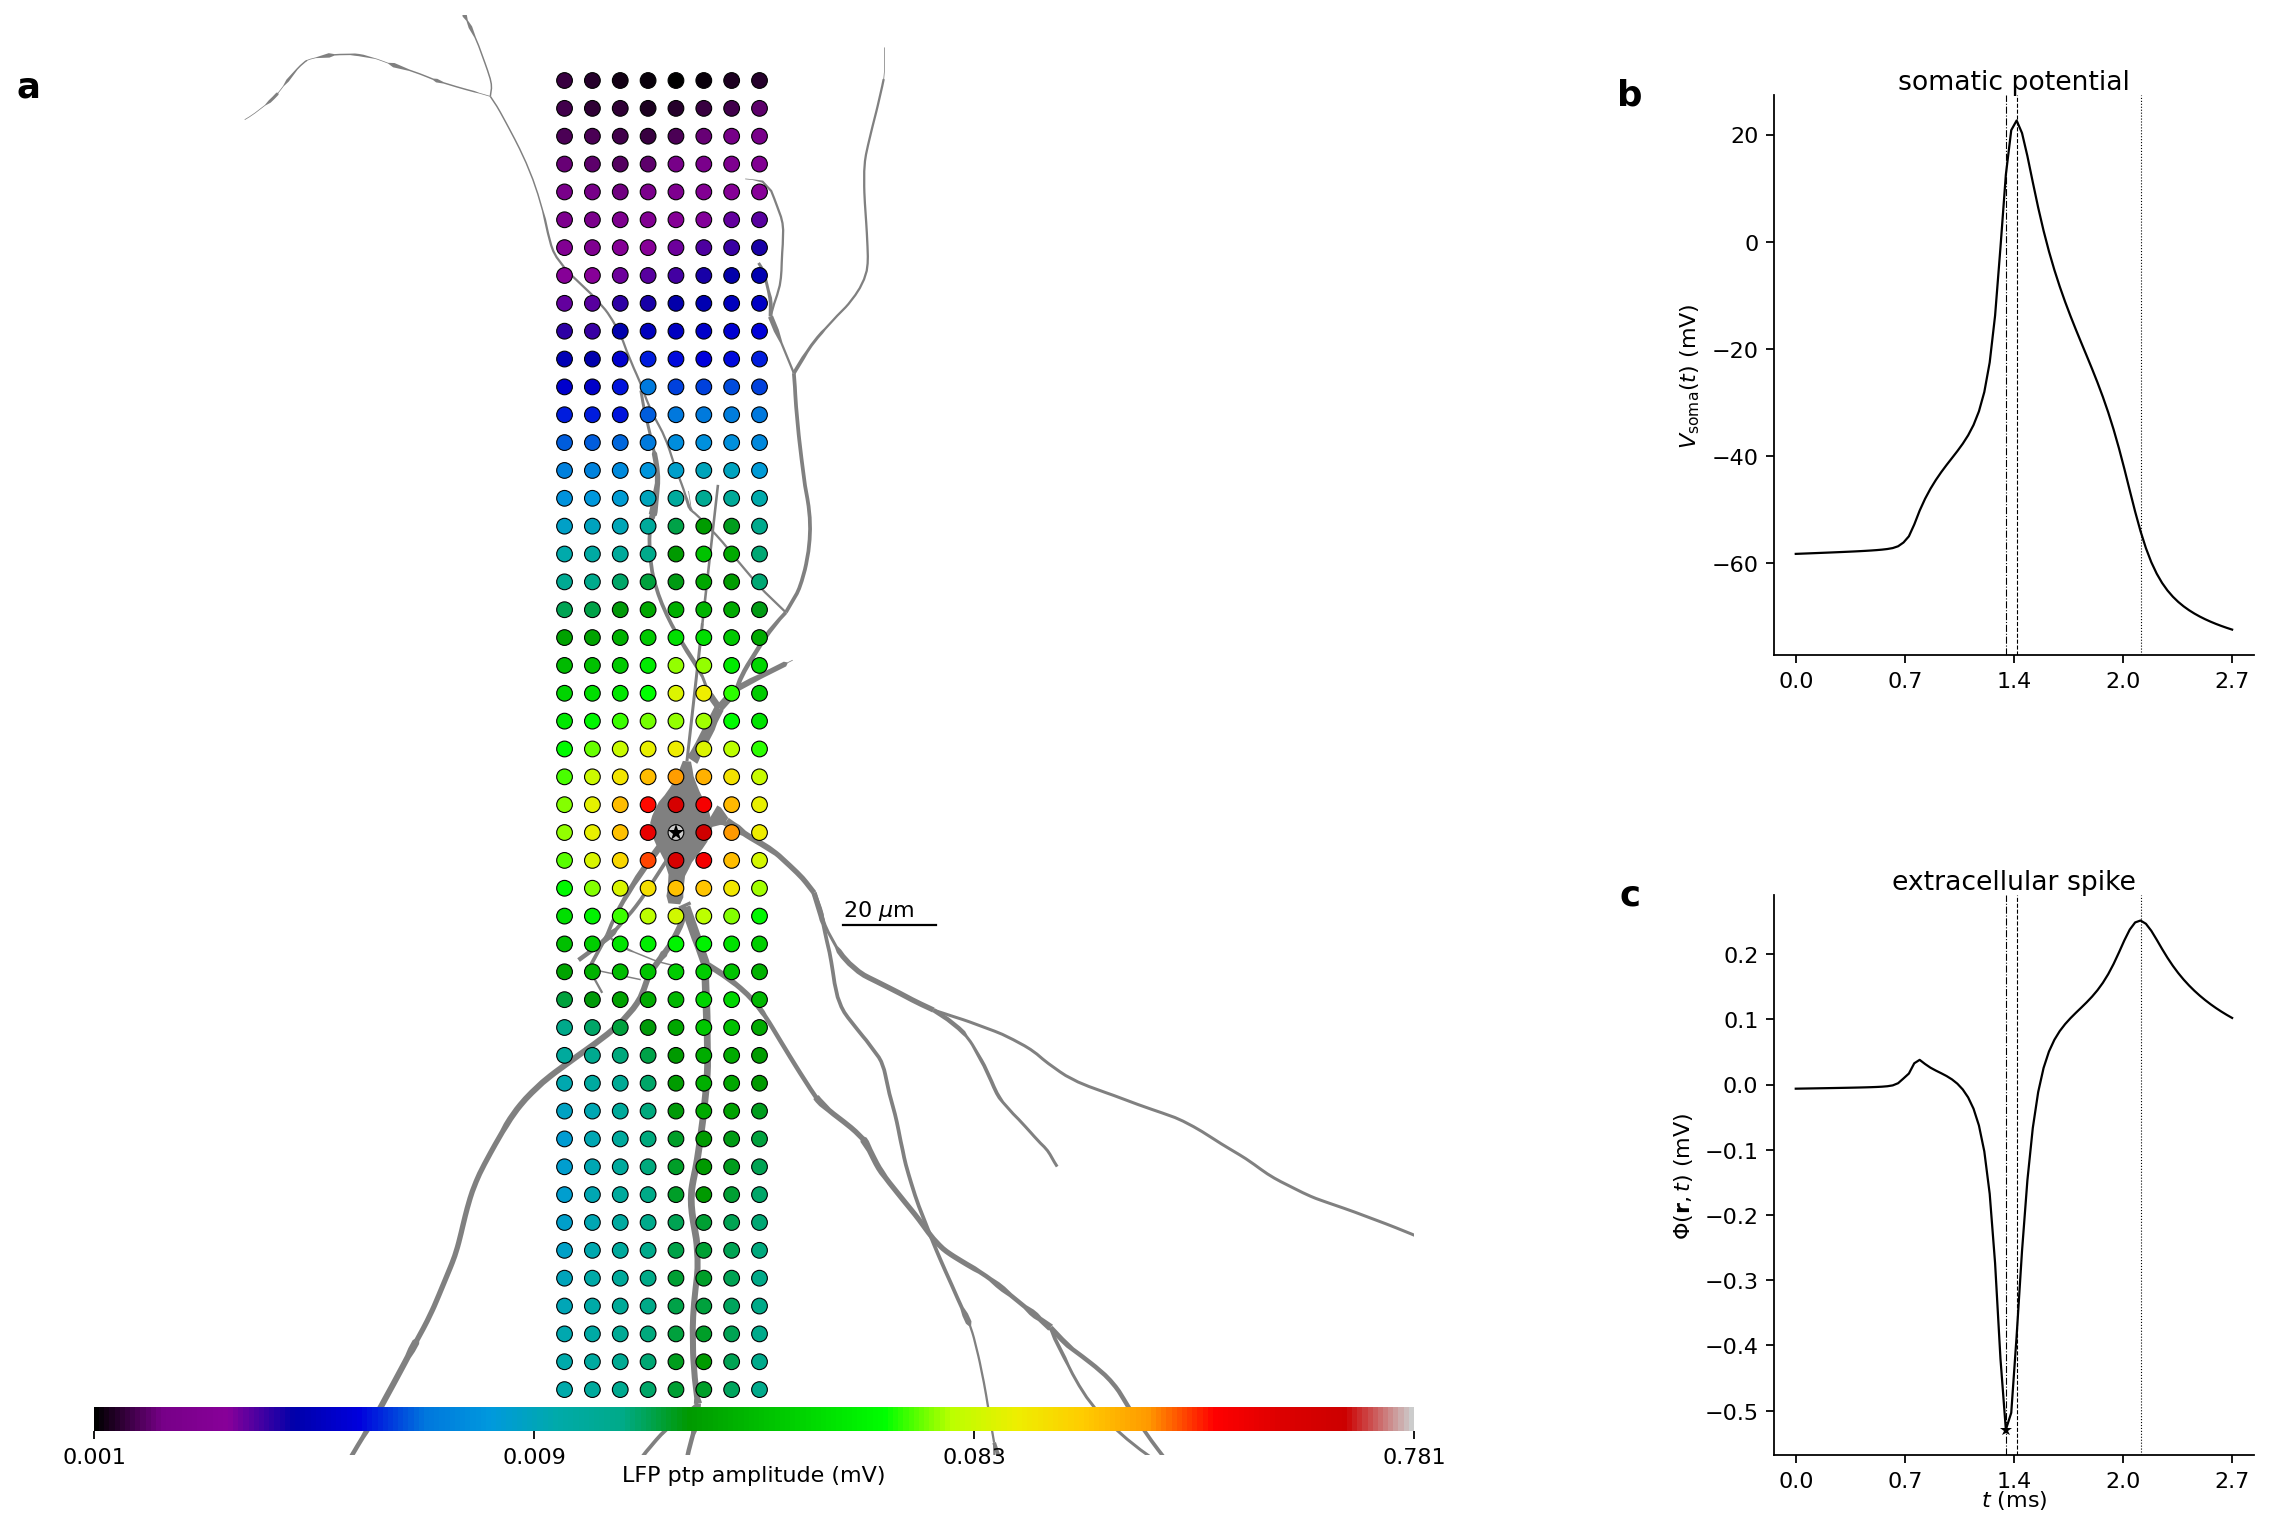

In [ ]:
my_cell2 = my_cell
my_cell2.imem = imem_filt2

fig = plotstuff(my_cell2, my_electrode, peak_mode='soma_max', n_total=82, debug=True)
plt.show()

# TESTING POSITION DISTRIBUTIONS

### Without distance restriction

In [ ]:
# NEW WITH LATIN HYPERCUBE 17.02.26
rng = np.random.default_rng(seed=26)
N = 4256

# Define slab bounds (microns): choose these to match "reasonable distance" from probe
x_min, x_max = -50.0, 100.0
y_min, y_max = -50.0, 50.0
z_min, z_max = -500.0, 800.0

U = latin_hypercube(rng, N, 3)  # Nx3 in [0,1]
x_pos = x_min + (x_max - x_min)*U[:,0]
y_pos = y_min + (y_max - y_min)*U[:,1]
z_pos = z_min + (z_max - z_min)*U[:,2]

positions = list(zip(x_pos.astype(float), y_pos.astype(float), z_pos.astype(float)))


### SANITY CHECK POSITION DISTRIBUTION

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# convert position list -> arrays
pos = np.asarray(positions, dtype=float)
x = pos[:,0]
y = pos[:,1]
z = pos[:,2]

N = len(pos)

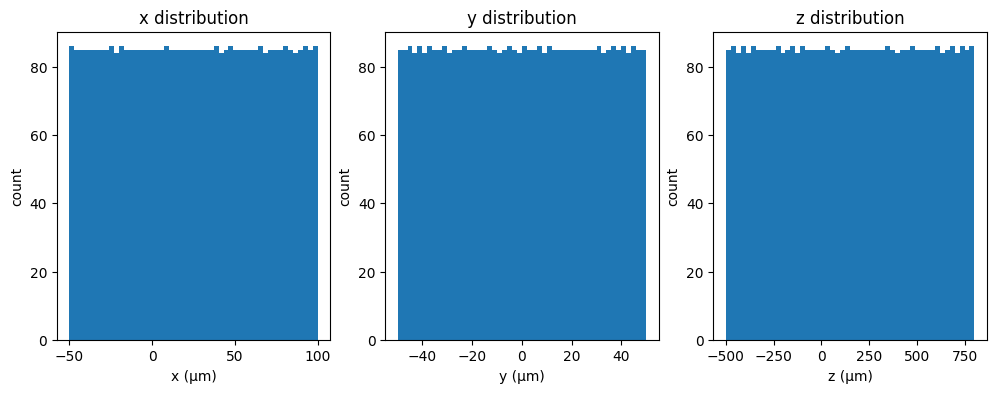

In [ ]:
# 1D distributions

fig, axes = plt.subplots(1,3, figsize=(12,4))

axes[0].hist(x, bins = 50)
axes[0].set_title('x distribution')
axes[0].set_xlabel('x (µm)')
axes[0].set_ylabel('count')

axes[1].hist(y, bins=50)
axes[1].set_title('y distribution')
axes[1].set_xlabel('y (µm)')
axes[1].set_ylabel('count')

axes[2].hist(z, bins=50)
axes[2].set_title('z distribution')
axes[2].set_xlabel('z (µm)')
axes[2].set_ylabel('count')

plt.show()

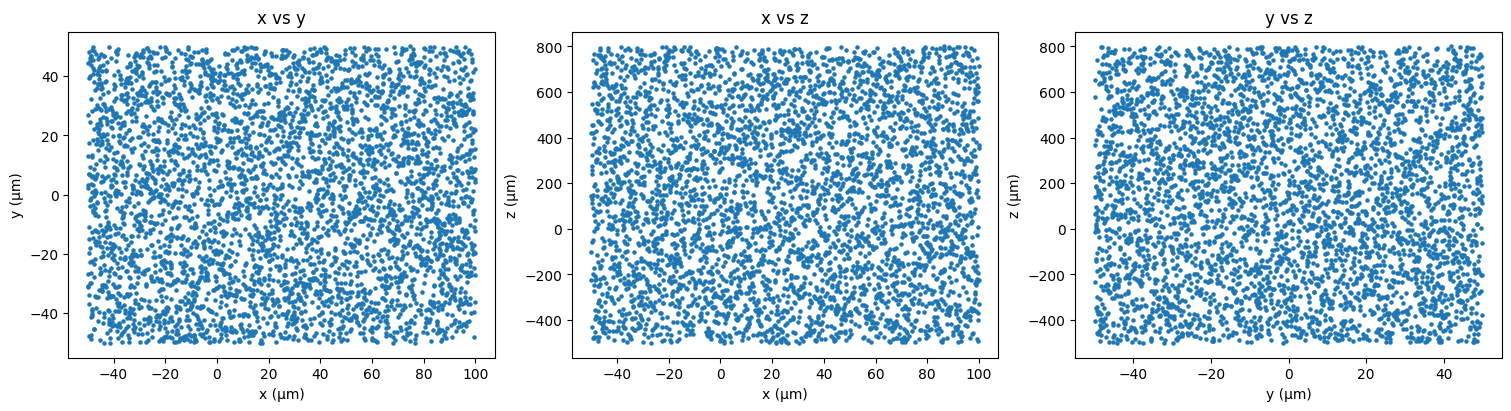

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].scatter(x, y, s=5)
axes[0].set_title("x vs y")
axes[0].set_xlabel("x (µm)")
axes[0].set_ylabel("y (µm)")

axes[1].scatter(x, z, s=5)
axes[1].set_title("x vs z")
axes[1].set_xlabel("x (µm)")
axes[1].set_ylabel("z (µm)")

axes[2].scatter(y, z, s=5)
axes[2].set_title("y vs z")
axes[2].set_xlabel("y (µm)")
axes[2].set_ylabel("z (µm)")

plt.show()


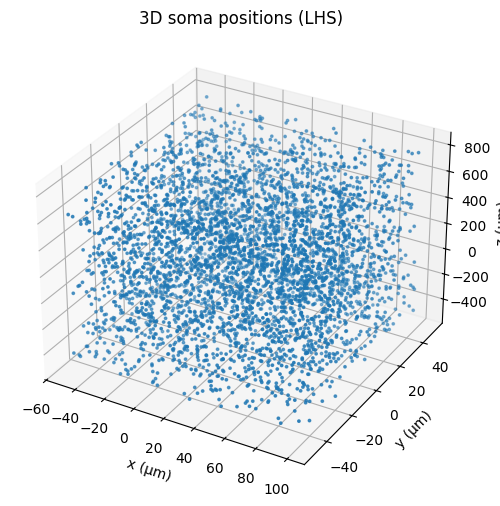

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x, y, z, s=3)

ax.set_title("3D soma positions (LHS)")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_zlabel("z (µm)")

plt.show()


### With distance restriction

In [ ]:
# fix random seed for reproducable positions
rng = np.random.default_rng(seed=27)
N = 5000  # test

# Define slab bounds (microns): choose these to match "reasonable distance" from probe
x_min, x_max = -30.0, 80.0
y_min, y_max = -30.0, 30.0
z_min, z_max = -100.0, 400.0

In [ ]:
contacts_xyz = np.column_stack([x_flat, y_plane, z_flat])  # (384,3)
bounds = ((x_min, x_max), (y_min, y_max), (z_min, z_max))
positions = sample_positions_lhs_with_minmax_dist(rng, N, bounds, contacts_xyz, d_min=5.0, d_max=70.0)

In [ ]:
# convert position list -> arrays
pos = np.asarray(positions, dtype=float)
x = pos[:,0]
y = pos[:,1]
z = pos[:,2]

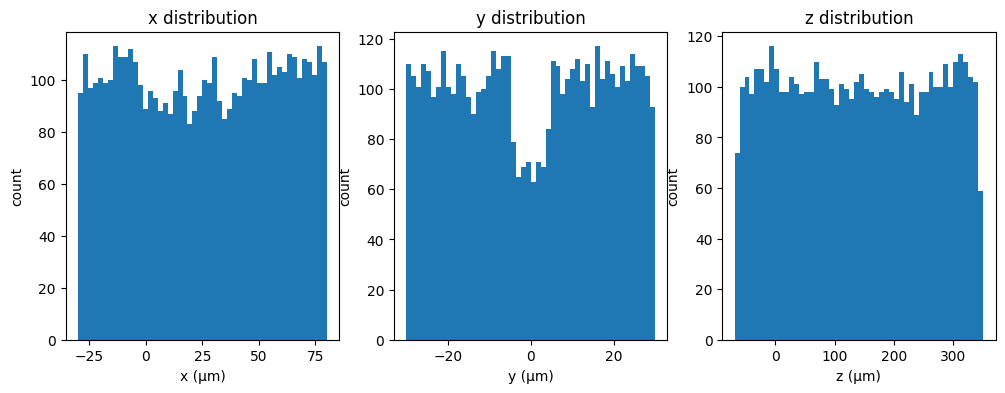

In [ ]:
# 1D distributions

fig, axes = plt.subplots(1,3, figsize=(12,4))

axes[0].hist(x, bins = 50)
axes[0].set_title('x distribution')
axes[0].set_xlabel('x (µm)')
axes[0].set_ylabel('count')

axes[1].hist(y, bins=50)
axes[1].set_title('y distribution')
axes[1].set_xlabel('y (µm)')
axes[1].set_ylabel('count')

axes[2].hist(z, bins=50)
axes[2].set_title('z distribution')
axes[2].set_xlabel('z (µm)')
axes[2].set_ylabel('count')

plt.show()

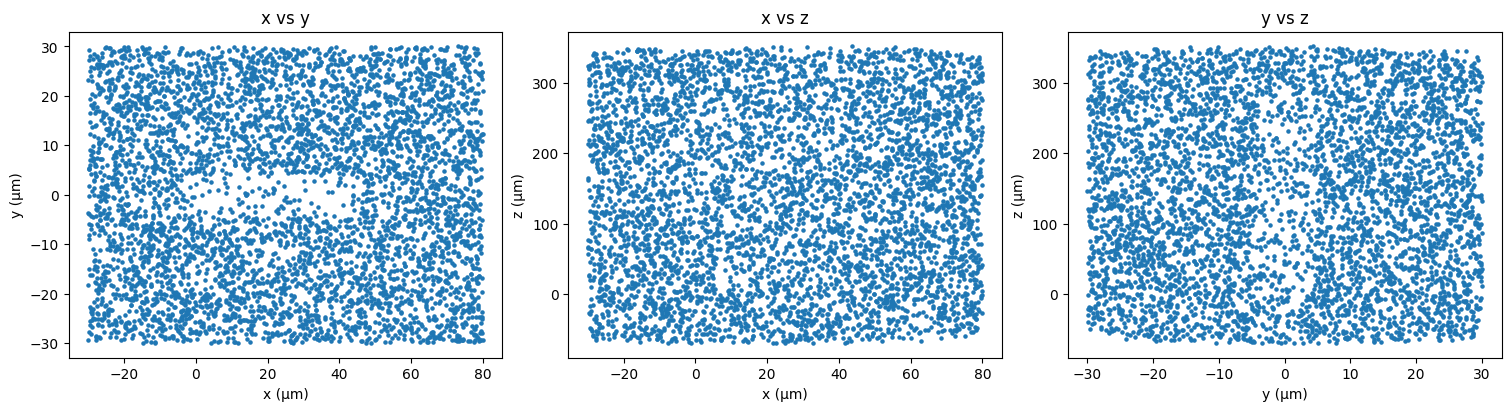

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].scatter(x, y, s=5)
axes[0].set_title("x vs y")
axes[0].set_xlabel("x (µm)")
axes[0].set_ylabel("y (µm)")

axes[1].scatter(x, z, s=5)
axes[1].set_title("x vs z")
axes[1].set_xlabel("x (µm)")
axes[1].set_ylabel("z (µm)")

axes[2].scatter(y, z, s=5)
axes[2].set_title("y vs z")
axes[2].set_xlabel("y (µm)")
axes[2].set_ylabel("z (µm)")

plt.show()

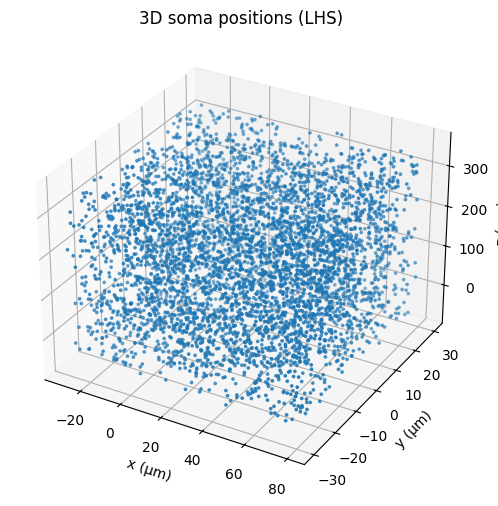

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x, y, z, s=3)

ax.set_title("3D soma positions (LHS)")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_zlabel("z (µm)")

plt.show()

In [ ]:
# delete dry-run files
!rm -f geometry.npy waveforms.dat progress.json

17.02.26:
Previously, we've drawn 16 x-values, 7 y-values and 38 x-values, and taken the Cartesian product to produce a 3D lattice. Even though each axis is "random", the product structure makes strong low-dimensional structure. PCA will happily find it. Instead, we now draw N independend 3D points (x_i, y_i, z_i), not a product grid.

# MC POSITION SWEEP

## PREPARATION: mount Drive, define dirs and paths

In [ ]:
# Mount drive and write everything into a folder
# Define run dirs and paths

import os, json, shutil
from google.colab import drive
drive.mount('/content/drive')

# CHANGE PER EXPERIMENT TO AVOID COLLISIONS!
# Change run name when changing bounds (x_min etc), d_min, d_max, seed, N, or delete positions.npy to avoid loading old positions
run_name = "run_003"
drive_dir = f"/content/drive/MyDrive/npultra_sims/{run_name}"
local_dir = f"/content/npultra_sims/{run_name}"

os.makedirs(drive_dir, exist_ok=True)
os.makedirs(local_dir, exist_ok=True)

wf_path_local = os.path.join(local_dir, "waveforms.dat")
geom_path_local = os.path.join(local_dir, "geometry.npy")
progress_path_local = os.path.join(local_dir, "progress.json")

wf_path_drive = os.path.join(drive_dir, "waveforms.dat")
geom_path_drive = os.path.join(drive_dir, "geometry.npy")
progress_path_drive = os.path.join(drive_dir, "progress.json")
meta_path_drive = os.path.join(drive_dir, "metadata.json")

# Resume consistency: pull latest checkpoint from Drive -> local
# If Drive has checkpoint, overwrite local copies so compute always resumes from persistent state
for src, dst in [
    (wf_path_drive, wf_path_local),
    (geom_path_drive, geom_path_local),
    (progress_path_drive, progress_path_local),
]:
  if os.path.exists(src):
    shutil.copy2(src, dst)


positions_path_drive = os.path.join(drive_dir, "positions.npy")
positions_path_local = os.path.join(local_dir, "positions.npy")
if os.path.exists(positions_path_drive):
    shutil.copy2(positions_path_drive, positions_path_local)

Mounted at /content/drive


## Get imem, synaptic input, transmembrane currents

In [ ]:
import gc
from tqdm import trange

# ==== 1) simulate once to get imem ====
LFPy.cell.neuron.h("forall delete_section()")
cell = LFPy.TemplateCell(**cellParameters)

# Keep orientation to match camera/plane
cell.set_rotation(x=4.749, y=-3.166)

# === 2) Synapse ====
# define synapse parameters
synapseParameters={
    'idx' : cell.somaidx[0],
    'syntype': 'Exp2Syn', # two-exponential synapse
    'e': 0.0, # reversal potential (mV), standard for excitatory synapse
    'tau1' : 0.5,
    'tau2' : 3.0,
    'weight': 0.05, # TBD
    'record_current': True,
}

# instantiate synapse
synapse = LFPy.Synapse(cell=cell, **synapseParameters)
input_spike_train = np.array([450.0])
synapse.set_spike_times(input_spike_train)

# ========================================================
# Run once, record transmembrane currents
cell.simulate(rec_imem=True, rec_vmem=True)

# Create filter
Fs = 1000/cell.dt
sos_spike = ss.ellip(N=1, rp = 0.1, rs = 40., Wn=[300., 10000.], btype='bp', fs=Fs, output='sos')

	1 
	1 
	1 


## Generate positions, enforce minimum distance from soma to recording site

In [ ]:
# ==== 2) Define sweep over positions, rotation fixed ====
# fix random seed for reproducable positions
rng = np.random.default_rng(seed=27)
N = 5000  # test

# Define slab bounds (microns): choose these to match "reasonable distance" from probe
x_min, x_max = -30.0, 80.0
y_min, y_max = -30.0, 30.0
z_min, z_max = -100.0, 400.0

contacts_xyz = np.column_stack([x_flat, y_plane, z_flat])  # (384,3)
bounds = ((x_min, x_max), (y_min, y_max), (z_min, z_max))

# save positions for safe resume
positions_path_drive = os.path.join(drive_dir, "positions.npy")

# Check local
if os.path.exists(positions_path_local):
  pos_arr = np.load(positions_path_local, allow_pickle=False)
  if pos_arr.shape != (N, 3):
    raise ValueError(f"positions.npy has shape {pos_arr.shape}, expected {(N,3)}.")
  positions = [tuple(map(float, row)) for row in pos_arr]
# Check Drive
elif os.path.exists(positions_path_drive):
  pos_arr = np.load(positions_path_drive, allow_pickle=False) # shape (N,3)
  if pos_arr.shape != (N, 3):
    raise ValueError(f"positions.npy has shape {pos_arr.shape}, expected {(N,3)}.")
  positions = [tuple(map(float, row)) for row in pos_arr]

else:
  positions = sample_positions_lhs_with_minmax_dist(rng, N, bounds, contacts_xyz, d_min=5.0, d_max=80.)
  np.save(positions_path_local, np.asarray(positions, dtype=np.float32))
  np.save(positions_path_drive, np.asarray(positions, dtype=np.float32))

assert len(positions) == N, f"positions length {len(positions)} != N {N}."

## Allocate output arrays

In [ ]:
# ==== 3) Allocate output arrays ====
T_snip = 82
n_contacts = x_flat.size      # 384

# Prepare outputs (memmap + geometry)
# Check size
if os.path.exists(wf_path_local):
  # size check
  expected_bytes = N*T_snip*n_contacts*np.dtype(np.float32).itemsize
  actual_bytes = os.path.getsize(wf_path_local)
  assert actual_bytes == expected_bytes, (
      f"Existing waveforms.dat has size {actual_bytes}, expected {expected_bytes}."
      "Delete it or adjust N/T_snip/n_contacts.")

mode = "r+" if os.path.exists(wf_path_local) else "w+"
wf = np.memmap(
    wf_path_local,
    mode=mode,
    dtype = np.float32,
    shape=(N, T_snip, n_contacts))


if os.path.exists(geom_path_local):
  geometry = np.load(geom_path_local, mmap_mode="r+") # update in-place
  assert geometry.shape == (N, 6), (
      f"Existing geometry.npy has shape {geometry.shape}, expected {(N,6)}"
  )
else:
  geometry = np.empty((N, 6), dtype=np.float32)                     # (x, y, z, rx, ry, rz)

# tiny progress file to resume
start_i = 0
if os.path.exists(progress_path_local):
  with open(progress_path_local, "r") as f:
    payload= json.load(f)
  start_i = int(payload.get("next_index", 0))

  if start_i > 0:
    # Must have existing local waveform + geometry files to resume safely
    if not os.path.exists(wf_path_local):
      raise RuntimeError("progress.json indicates resume, but waveforms.dat is missing locally.")
    if not os.path.exists(geom_path_local):
      raise RuntimeError("progress.json indicates resume, but geometry.npy is missing locally.")
    if start_i > N:
      raise RuntimeError(f"progress.json next_index={start_i} exceeds N={N}. Check run_name/N mismatch.")

BATCH_FLUSH = 200 # flush every 200 iterations

## Create meta file

In [ ]:
meta = {
    "note" : "L5 MC - Position sweep along x, y, z with fixed rotation. Synapse activation. Waveforms centered and clipped to 82 samples.",
    "shape": [N, T_snip, n_contacts],
    "order": "C",
    "waveforms_dat": os.path.basename(wf_path_drive),
    "geometry_npy": os.path.basename(geom_path_drive),
    "positions_npy": "positions.npy",
    "progress_json": os.path.basename(progress_path_drive),
    "filter": {"type": "ellip", "band": [300.0, 10000.0], "order": 1, "rp": 0.1, "rs": 40.0, "fs_hz": float(Fs)},
    "position_bounds": {"x": [x_min, x_max], "y": [y_min, y_max], "z": [z_min, z_max]},
    "distance_constraints_um": {"d_min": 5.0, "d_max": 80.0},
    "seed": 26,
    "position_sampling": {"method": "latin_hypercube_rejection_minmax_dist", "seed":27, "N":N},
    "centering": {"mode": "lfp_min_best_channel", "window_samples": T_snip},
    "cellParameters": {k: _to_native(v) for k, v in cellParameters.items()},
    "electrodeParameters": {k: _to_native(v) for k, v in electrodeParameters.items()},
    "synapseParameters": {k: _to_native(v) for k, v in synapseParameters.items()},
}

with open(meta_path_drive, "w") as f:
  json.dump(meta, f, indent=2)

## POSITION LOOP

In [ ]:

# ==== 4) Loop: rigid transform, forward model, center & window, store ====

RX = RY = RZ = 0.0  # fixed rotation for this sweep (radians)

for i in trange(start_i, N, desc="Position sweep - L5 MC"):
  pos_x, pos_y, pos_z = positions[i]

  # (a) set absolute position
  cell.set_pos(x=pos_x, y=pos_y, z=pos_z)

  # (b) we will worry about the rotation sweep later

  # (c) build electrode for this geometry
  electrode = LFPy.RecExtElectrode(cell=cell, **electrodeParameters)
  M = electrode.get_transformation_matrix()     # (n_contacts, n_segments)

  if i == start_i:
    assert M.shape[0] == n_contacts, f"n_contacts mismatch: {M.shape[0]} vs. {n_contacts}"

  # (d) compute forward mapping (lfp)
  # FOR FULL CELL MODEL PARAMETER SWEEP
  lfp = M @ cell.imem                           # (n_contacts, T)

  # Find peak_idx per position
  # best channel = channel with most negative deflection
  best_ch = np.argmin(lfp.min(axis=1))
  # trough time index on that channel
  peak_idx = int(np.argmin(lfp[best_ch]))

  # Window around peak_idx
  (_, _), sl = extract_snippet_around(peak_idx, lfp[best_ch], n_total=T_snip, tvec=cell.tvec)

  lfp_snip = lfp[:, sl]   # (C, 82)
  # Assert shape before filtering
  assert lfp_snip.shape == (n_contacts, T_snip), f"lfp_snip has shape {lfp_snip.shape}, expected{(n_contacts, T_snip)}"

  # Apply spike-band filter only to the snippet, filter along time axis (last axis)
  lfp_snip = ss.sosfiltfilt(sos_spike, lfp_snip, axis=-1)

  # Store as (T_snip, n_contacts)
  wf[i] = lfp_snip.T

  # (f) store geometry (soma position + rotation)
  # Try the most common soma accessor, fall back if needed
  try:
    sx, sy, sz = np.asarray(cell.somapos, float).ravel()
  except Exception:
    # generic fallback: soma is section 0, segment 0 center - this may vary by template
    sx, sy, sz = float(cell.x[0][0]), float(cell.y[0][0]), float(cell.z[0][0])

  # For position sweep with fixed rotation, rx, ry and rz are zero
  geometry[i] = (sx, sy, sz, RX, RY, RZ)

  # (g) periodic flush + checkpoint
  if (i+1)% BATCH_FLUSH == 0:
    wf.flush()
    # save geometry incrementally, safe overwrite
    np.save(geom_path_local, geometry)
    with open(progress_path_local, "w") as f:
      json.dump({"next_index": i+1}, f)
    gc.collect()

    # copy to drive (overwrite chekcpoints)
    shutil.copy2(wf_path_local, wf_path_drive)
    shutil.copy2(geom_path_local, geom_path_drive)
    shutil.copy2(progress_path_local, progress_path_drive)

  # (h) free big temps
  del electrode, M, lfp, lfp_snip, best_ch, peak_idx, sl

# (i) final flush + checkpoint cleanup
wf.flush()
np.save(geom_path_local, geometry)
with open(progress_path_local, "w") as f:
  json.dump({"next_index": N}, f)

shutil.copy2(wf_path_local, wf_path_drive)
shutil.copy2(geom_path_local, geom_path_drive)
shutil.copy2(progress_path_local, progress_path_drive)

Position sweep - L5 MC: 100%|██████████| 5000/5000 [4:37:38<00:00,  3.33s/it]


'/content/drive/MyDrive/npultra_sims/run_003/progress.json'